(05-33-fama-vs-shiller)=

# Fama, Shiller en "Discount Rates"

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1998–2017: van Fama's verdediging van efficiënte markten via de Nobelprijs
van 2013 en Cochrane's presidentiële rede tot de eerste modellen die enquêtes over
verwachtingen serieus nemen.

**Wat we al weten.** De prijs-dividend-ratio voorspelt rendementen en geen dividenden
([](#04-20-voorspelbaarheid)); koersen bewegen meer dan dividendnieuws kan dragen
([](#03-15-shiller-excess-volatility)). Drie consumptiemodellen maken daar een rationele
discontovoet van, maar zijn op honderd jaar data niet van elkaar te onderscheiden
([](#05-27-drie-antwoorden)), en in [](#05-32-intermediaries) bleek dat ook de premies
die in 2008 explodeerden, zowel beprijsd risico als gedwongen mispricing kunnen zijn. In
[](#04-23-behavioral) zagen we al dat een risico-economie en een sentimenteconomie
dezelfde prijzen kunnen maken.

**Welke vraag staat open.** Als iedereen het over de feiten eens is, welke data zou dan
kunnen beslissen of een variërende discontovoet risico of vergissing is?
```

## Overzicht

In oktober 2013 kende het Nobelcomité de prijs voor economie toe aan Eugene Fama, Lars
Peter Hansen en Robert Shiller, "for their empirical analysis of asset prices". De
wetenschappelijke toelichting van het comité heette eenvoudig *Understanding Asset
Prices* {cite}`NobelCommittee2013`. Dat Fama en Shiller de prijs deelden, werd breed als
grap gelezen. Santa-Clara leest het anders: het was "a precise description of the
field's condition". Beide hadden gelijk over de feiten; "They disagreed about what the
facts meant, and the committee, wisely, declined to decide" {cite}`SantaClara2026`. Elders
in dezelfde terugblik staat de korte versie: de twee kampen "agreed about almost every
fact and almost no interpretation".

Deze lecture sluit deel V af en is de synthese van twee motieven. Motief 2 (risico
versus vergissing) krijgt hier zijn formele vorm: we bewijzen dat prijzen en dividenden
alleen het *product* van overtuigingen en marginaal nut identificeren, zodat een
rationele economie met tijdvariërende risicoaversie en een economie met extrapolerende
beleggers exact dezelfde prijzen kunnen maken. Motief 3 krijgt zijn scharnier: volgens
Santa-Clara veranderde het vak "from a theory with tests to a body of facts with
competing theories, and the prize made the change official". Het feit waar alles om
draait, vatte Cochrane in zijn presidentiële rede samen {cite}`Cochrane2011`: "Now it
seems all price-dividend variation corresponds to discount-rate variation." Waarom de
discontovoet varieert, daarover lopen de Nobellezingen van Fama {cite}`Fama2014` en
Shiller {cite}`Shiller2014` uiteen, en Hansen {cite}`Hansen2014` maakt er een vraag van
over onzekerheid binnen en buiten economische modellen. Epistemisch is dit het moment
waarop een feit (variërende discontovoeten) definitief op meerdere theorieën wacht, in
plaats van één theorie op haar toets.

We herhalen de replicaties van eerdere lectures niet. Het toy-voorbeeld rekent twee
economieën met hetzelfde prijspad met de hand door. De theorie bewijst de
observationele gelijkwaardigheid in het algemeen en laat zien welke extra data
(enquêtes, opties, flows) haar kan doorbreken. De simulatie laat zien dat honderd jaar
koersen de twee economieën niet scheidt, maar enkele decennia enquêtes wel. De
replicatie rapporteert Cochrane's variantiedecompositie van 2011, zet de verwachtingen
van financieel directeuren uit de CFO-enquête naast de prijs-dividend-ratio en latere
rendementen, zoals Greenwood en Shleifer {cite}`GreenwoodShleifer2014` met zes enquêtes
deden, en werkt Shillers CAPE-voorspelling bij tot nu.

In [1]:
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import statsmodels.api as sm
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Beide kampen zijn het over drie feiten eens. Op korte termijn zijn koersen nauwelijks te
voorspellen, en wie de markt na kosten wil verslaan, faalt bijna altijd. Op lange termijn
voorspellen waarderingsratio's zoals de dividend-prijsratio en Shillers CAPE de rendementen
wel, en vrijwel niets anders. En de prijs-dividend-ratio beweegt veel meer dan het
dividendnieuws dat haar zou moeten bewegen. Het tweede en derde feit zijn hetzelfde feit:
als de ratio geen dividenden voorspelt, moet ze rendementen voorspellen, anders kan ze
niet bewegen.

Het meningsverschil gaat over één woord: *waarom* is het verwachte rendement hoog als de
prijs laag is? Het Chicago-antwoord: omdat beleggers dan meer eisen. Na een crash zijn
mensen armer, banger en dichter bij hun gewoonte, of hebben hun intermediairs geen
kapitaal meer. Ze willen alleen aandelen houden als die goedkoop zijn. Wie dan koopt,
verkoopt verzekering aan wie die op dat moment het hardst nodig heeft, en wordt daarvoor
betaald. Het Yale-antwoord: omdat beleggers zich vergissen. Na een reeks goede jaren
verwachten ze meer goede jaren, bieden ze de prijs op, en de lage rendementen daarna zijn
de langzame correctie. Na een crash is het omgekeerd.

Waarom kunnen koersen dit niet beslissen? Omdat een prijs een verwachting maal een
weging is. Een lage prijs kan betekenen dat beleggers de toekomst somber *inschatten*,
of dat ze een gegeven toekomst zwaar *wegen*. Een aandeel dat in slechte tijden slecht
uitbetaalt, is weinig waard voor wie slechte tijden waarschijnlijk vindt, en evenveel
voor wie slechte tijden erg vindt. Uit de prijs zie je alleen het product. Dat is de
joint hypothesis van [](#02-06-efficiente-markten) in haar scherpste vorm, en er is
geen hoeveelheid koersdata die haar oplost.

Wat haar wel kan oplossen, is een meting van een van de twee factoren apart. Vraag
beleggers wat ze verwachten. Als de Chicago-lezing klopt, verwachten beleggers na een
crash *hoge* rendementen: ze weten dat aandelen goedkoop zijn, en dat is precies wat ze
eisen. Als de Yale-lezing klopt, verwachten ze na een crash *lage* rendementen: ze
extrapoleren de slechte jaren. De twee lezingen voorspellen bij dezelfde prijs het
tegenovergestelde teken van de enquête. Greenwood en Shleifer vonden het teken van
Yale: verwachtingen zijn hoog als prijzen hoog zijn, en juist dan zijn latere
rendementen laag. Dat is het sterkste bewijs tegen de zuiver rationele lezing, maar geen
beslissend bewijs, want een enquête meet wat mensen *zeggen*, en niet noodzakelijk wat
de belegger denkt die de prijs zet.

Het 2%-motief speelt hier een onverwachte rol. Een voorspellingsregressie van
rendementen heeft zeventig à tachtig jaar nodig om iets te zien, omdat het gerealiseerde
rendement de voorspelbare component verdrinkt in twintig procent ruis per jaar. Een
regressie van enquêteverwachtingen op de prijs heeft die ruis niet: links staat geen
uitkomst, maar een overtuiging. Daarom kunnen een paar decennia enquêtedata zeggen wat
een eeuw koersdata niet kan.

## Toy-voorbeeld: twee economieën, één prijspad, drie perioden

Vanaf hier zijn kleine letters logs, $dp_t = d_t - p_t$ is de log dividend-prijsratio
(hoog is goedkoop), en alle grootheden zijn afwijkingen van hun gemiddelde. Het rendement
volgt uit de Campbell-Shiller-benadering van [](#04-20-voorspelbaarheid):
$r_{t+1} = dp_t - \rho\, dp_{t+1} + \Delta d_{t+1}$, met $\rho = 0{,}96$.

**Het gemeenschappelijke prijspad.** De log dividend-prijsratio is
$dp_0 = 0{,}10$, $dp_1 = 0{,}00$, $dp_2 = -0{,}10$, $dp_3 = 0{,}05$, en de
dividendgroei is $\Delta d_1 = 0{,}02$, $\Delta d_2 = -0{,}01$, $\Delta d_3 = 0{,}00$.
Dan is

$$
\begin{aligned}
r_1 &= \phantom{-}0{,}10 - 0{,}96 \times 0{,}00 + 0{,}02 = \phantom{-}0{,}120, \\
r_2 &= \phantom{-}0{,}00 - 0{,}96 \times (-0{,}10) - 0{,}01 = \phantom{-}0{,}086, \\
r_3 &= -0{,}10 - 0{,}96 \times 0{,}05 + 0{,}00 = -0{,}148 .
\end{aligned}
$$

**De voorspellingsregressie.** De regressor $x = (0{,}10;\ 0{,}00;\ -0{,}10)$ heeft
gemiddelde nul en $\sum x^2 = 0{,}02$, dus de helling is
$\hat b_r = \sum x\,r / 0{,}02 = (0{,}012 + 0 + 0{,}0148)/0{,}02 = 1{,}34$. Een goedkope markt
voorspelt een hoog rendement. Deze regressie is in beide economieën dezelfde, want ze
gebruikt alleen prijzen en dividenden.

**Economie (a): rationeel, met tijdvariërende risicoaversie.** De representatieve
belegger eist een verwacht rendement $x_t$ boven het gemiddelde, dat traag terugkeert:
$\E_t[x_{t+1}] = \phi\, x_t$ met $\phi = 0{,}5$. Verwachte dividendgroei is constant. Uit
de Campbell-Shiller-identiteit volgt $dp_t = \sum_{j \ge 1}\rho^{j-1}\E_t[x_{t+j-1}] =
x_t/(1-\rho\phi)$. Met $1 - \rho\phi = 1 - 0{,}48 = 0{,}52$ horen bij het prijspad
de eisen $x_0 = 0{,}052$, $x_1 = 0$ en $x_2 = -0{,}052$. In jaar 0 is de markt goedkoop
omdat beleggers 5,2 procentpunt extra eisen.

**Economie (b): constante vereiste premie, extrapolerende beleggers.** Fundamentele
beleggers disconteren tegen een constante discontovoet, dus de fundamentele ratio
$dp^{*}_t$ is constant (nul). De prijs wijkt af door het sentiment $s_t$ van
extrapolerende beleggers, $p_t - p^{*}_t = s_t$, dat met dezelfde snelheid $\phi = 0{,}5$
uitdooft. Het prijspad vraagt $s_0 = -0{,}10$, $s_1 = 0$, $s_2 = 0{,}10$: in jaar 0 zijn de
extrapolatoren somber, in jaar 2 euforisch. Het *objectieve* verwachte rendement is
$\E_t[r_{t+1}] = dp_t - \rho\phi\, dp_t = 0{,}52\, dp_t$, dus $0{,}052$, $0$ en $-0{,}052$:
precies hetzelfde als in (a), want het is dezelfde identiteit op hetzelfde pad.

**De enquête.** Nu vragen we in beide economieën wat beleggers verwachten. In (a)
antwoordt de rationele belegger met zijn eigen eis, $\E^{s}_t = x_t$. In (b) antwoorden
de extrapolatoren, die het rendement verwachten dat bij hun stemming past:
$\E^{s}_t = \theta\, s_t$, met $\theta = 0{,}52$ zodat de schaal gelijk is. De tabel:

| $t$ | $dp_t$ | $r_{t+1}$ | $\E_t[r_{t+1}]$, (a) én (b) | enquête (a) | enquête (b) |
|---|---|---|---|---|---|
| 0 | 0,10 | 0,120 | 0,052 | 0,052 | −0,052 |
| 1 | 0,00 | 0,086 | 0,000 | 0,000 | 0,000 |
| 2 | −0,10 | −0,148 | −0,052 | −0,052 | 0,052 |

De helling van de enquête op $dp$ is in (a) $(0{,}10 \times 0{,}052 + 0{,}10 \times
0{,}052)/0{,}02 = 0{,}52$ en in (b) $-0{,}52$. Omdat $pd = -dp$, is de correlatie van de
enquête met de prijs-dividend-ratio in (a) $-1$ en in (b) $+1$. En wie het gerealiseerde
rendement op de enquête regresseert, vindt in (a) $\sum \E^{s} r/\sum (\E^{s})^2 =
0{,}013936/0{,}005408 = 2{,}5769$ en in (b) $-2{,}5769$. In (a) voorspellen hoge
verwachtingen hoge rendementen; in (b) lage.

Prijzen, dividenden, rendementen en de voorspellingsregressie zijn in beide economieën
identiek. Alleen de enquête scheidt ze, en met het tegenovergestelde teken.

In [2]:
RHO_TOY, PHI_TOY = 0.96, 0.50
K_TOY = 1 - RHO_TOY * PHI_TOY
dp_toy = np.array([0.10, 0.00, -0.10, 0.05])
dd_toy = np.array([0.02, -0.01, 0.00])
r_toy = dp_toy[:-1] - RHO_TOY * dp_toy[1:] + dd_toy
x_toy = dp_toy[:-1]


def ols_slope(y, x):
    """OLS slope of y on x with an intercept."""
    xd = x - x.mean()
    return float((xd * (y - y.mean())).sum() / (xd**2).sum())


required_a = K_TOY * x_toy                          # (a): the rational investor's required return
sentiment_b = -x_toy                                # (b): p - p* with a constant-discount-rate p*
objective_b = x_toy - RHO_TOY * PHI_TOY * x_toy     # (b): E_t[r] from the identity
survey_toy = {"a": required_a, "b": K_TOY * sentiment_b + 0.0}   # + 0.0 avoids a printed -0.0

toy = pd.DataFrame(
    {"dp_t": x_toy, "r_t+1": r_toy, "E_t[r] (a)": required_a, "E_t[r] (b)": objective_b,
     "enquête (a)": survey_toy["a"], "enquête (b)": survey_toy["b"]},
    index=pd.Index([0, 1, 2], name="t"),
)
print(f"b_r (beide economieën)        : {ols_slope(r_toy, x_toy):.4f}   (hand: 1.3400)")
for e, sign in [("a", "+"), ("b", "-")]:
    print(f"({e}) enquête op dp            : {ols_slope(survey_toy[e], x_toy):+.4f}   (hand: {sign}0.5200)")
    print(f"({e}) corr(enquête, pd = -dp)  : {np.corrcoef(survey_toy[e], -x_toy)[0, 1]:+.1f}")
    print(f"({e}) r op enquête             : {ols_slope(r_toy, survey_toy[e]):+.4f}   (hand: {sign}2.5769)")
toy.round(4)

b_r (beide economieën)        : 1.3400   (hand: 1.3400)
(a) enquête op dp            : +0.5200   (hand: +0.5200)
(a) corr(enquête, pd = -dp)  : -1.0
(a) r op enquête             : +2.5769   (hand: +2.5769)
(b) enquête op dp            : -0.5200   (hand: -0.5200)
(b) corr(enquête, pd = -dp)  : +1.0
(b) r op enquête             : -2.5769   (hand: -2.5769)


,dp_t,r_t+1,E_t[r] (a),E_t[r] (b),enquête (a),enquête (b)
t,,,,,,
0,0.1,0.120,0.052,0.052,0.052,-0.052
1,0.0,0.086,0.000,0.000,0.000,0.000
2,-0.1,-0.148,-0.052,-0.052,-0.052,0.052


De code geeft dezelfde getallen. Let op wat er níet in de tabel staat: niets in de
kolommen $dp_t$ en $r_{t+1}$ verraadt welke economie de data maakte.

## Theorie

### Het feit: Cochrane's decompositie in één schema

*Waarom zou dit waar zijn?* Een hoge dividend-prijsratio moet vroeg of laat worden
"terugbetaald": door hoge rendementen, door lage dividendgroei, of doordat de ratio
over $k$ jaar nog steeds hoog is. Er is geen vierde uitweg. Regresseer elk van die drie
toekomstige grootheden op de ratio van vandaag, en de hellingen moeten optellen tot
één. Welke helling het werk doet, is een empirische vraag.

In [](#04-20-voorspelbaarheid) leidden we [](#eq-voorspelbaarheid-lr) af voor een
oneindige horizon. Cochrane {cite}`Cochrane2011` schrijft de eindige-horizonversie,
met lange-termijncoëfficiënten $b^{(k)}$ uit regressies van
$\sum_{j=1}^{k}\rho^{j-1}r_{t+j}$, $\sum_{j=1}^{k}\rho^{j-1}\Delta d_{t+j}$ en
$dp_{t+k}$ op $dp_t$:

```{math}
:label: eq-fama-vs-shiller-schema
1 \;\approx\;
\underbrace{b_r^{(k)}}_{\text{verwachte rendementen}}
\;-\;
\underbrace{b_d^{(k)}}_{\text{verwachte dividendgroei}}
\;+\;
\underbrace{\rho^{k}\, b_{dp}^{(k)}}_{\text{ratio over } k \text{ jaar (bel als } k\to\infty)} .
```

Zijn tabel II, jaardata 1947–2009, vult het schema zo in: met directe regressies over
$k = 15$ jaar $1{,}01$, $-0{,}11$ en $-0{,}11$; geïmpliceerd door een VAR met $k = 15$
$1{,}05$, $0{,}27$ en $0{,}22$; en voor $k = \infty$ $1{,}35$, $0{,}35$ en $0{,}00$. Zijn
conclusie: "the estimates say that all price-dividend ratio volatility corresponds to
variation in expected returns. None corresponds to variation in expected dividend
growth, and none to rational bubbles." In de jaren zeventig had men het omgekeerde
verwacht; in zijn woorden: "What we expected to be 0 is 1; what we expected to be 1
is 0."

Het schema zegt dus met grote precisie *dat* de discontovoet beweegt. Over *waarom*
zegt het niets. $b_r^{(k)}$ is een covariantie tussen een prijs en latere rendementen;
het is dezelfde covariantie in een economie waar beleggers rationeel meer eisen en in een
economie waar ze zich vergissen. Cochrane noemt variatie in discontovoeten daarom "the
central organizing question of current asset pricing research", een vraag en geen
antwoord.

### De joint hypothesis opnieuw, en wat "efficiënt" betekent als discontovoeten variëren

*Waarom zou dit waar zijn?* Fama's definitie van 1970 zegt dat prijzen alle beschikbare
informatie "fully reflect". Dat is pas toetsbaar als je zegt welk verwacht rendement een
correcte prijs zou opleveren. Zolang dat verwachte rendement constant werd verondersteld,
betekende efficiëntie in de praktijk: onvoorspelbare rendementen. Zodra het mag variëren,
valt die toets weg, en moet de inhoud van het woord ergens anders vandaan komen.

In [](#02-06-efficiente-markten) bewezen we dat elk patroon van voorspelbaarheid een
positieve SDF heeft die het prijst ({prf:ref}`thm-efficiente-markten-elke-sdf`). Een
voorspellende dividend-prijsratio is dus geen bewijs tegen efficiëntie, alleen tegen de
combinatie "efficiënt en constante discontovoet". Fama {cite}`Fama1991` formuleerde het
zo: efficiëntie "must be tested jointly with some model of equilibrium, an asset-pricing
model". Zijn Nobellezing heet daarom *Two Pillars of Asset Pricing*
{cite}`Fama2014`: efficiëntie en prijsmodellen zijn twee pijlers die alleen samen te
toetsen zijn.

Als discontovoeten variëren, verschuift de inhoud van "efficiënt" van rendementen naar
*verwachtingen*. Een markt is efficiënt als de verwachtingen in de prijs dezelfde zijn als
die van een econometrist met dezelfde informatie; welke weging beleggers aan toestanden
geven, is dan een kwestie van voorkeuren, en die mag alles zijn wat de
Hansen-Jagannathan-grens van [](#03-13-equity-premium-puzzle) toelaat. Een markt is
inefficiënt als de verwachtingen in de prijs systematisch afwijken. Dat is geen spel met
woorden: het maakt van de vraag een meetprobleem, en de volgende twee subsecties laten
zien welk meetprobleem.

Fama's verdediging tegen de anomalieën van de behavioral finance liep langs dezelfde weg.
In zijn artikel van 1998 {cite}`Fama1998` betoogde hij dat de lange-termijnanomalieën
de toets als bewijs voor *systematische vergissingen* niet doorstaan: schijnbare
overreactie komt ongeveer even vaak voor als onderreactie, voortzetting na een
gebeurtenis ongeveer even vaak als omkering, en de meeste anomalieën verdwijnen bij
redelijke veranderingen in de methode. Onder toevalsresultaten verwacht je precies dat
patroon; onder een gedeelde vergissing een vaste richting. (De bewoording hier is een
parafrase; de tekst van het artikel konden we niet inzien.) Het argument is sterk tegen
losse anomalieën, maar raakt de dividend-prijsratio niet: die voorspelt over een eeuw
steeds met hetzelfde teken.

### Observationele gelijkwaardigheid, formeel

*Waarom zou dit waar zijn?* Een prijs is een som over toestanden van kans maal weging
maal uitbetaling. Verdubbel de kans op een toestand en halveer de weging, en de prijs blijft
gelijk. Wie alleen prijzen ziet, kan kans en weging nooit uit elkaar halen. En zolang de
toestanden zelf, de dividenden, volgens de ware kansen worden getrokken, zien ook de
gerealiseerde rendementen er in beide gevallen hetzelfde uit.

Laat $\mathbb P$ de objectieve kansmaat zijn en $m_{t+1} > 0$ een SDF, zodat prijzen
voldoen aan $p_t = \E_t[m_{t+1}x_{t+1}]$. Een belegger met *subjectieve* overtuigingen
$\tilde{\mathbb P}$ gebruikt verwachtingen $\tilde\E_t$. Als $\tilde{\mathbb P}$ en
$\mathbb P$ dezelfde gebeurtenissen onmogelijk vinden, is er een dichtheid
$\xi_{t+1} = d\tilde{\mathbb P}/d\mathbb P > 0$ met $\E_t[\xi_{t+1}] = 1$ en
$\tilde\E_t[z] = \E_t[\xi_{t+1}z]$ voor elke $z$.

:::{prf:proposition} Prijzen identificeren alleen het product van overtuigingen en marginaal nut
:label: prop-fama-vs-shiller-equivalentie

1. Voor elke dichtheid $\xi_{t+1} > 0$ met $\E_t[\xi_{t+1}] = 1$ geldt, met
   $\tilde m_{t+1} = m_{t+1}/\xi_{t+1}$,

   ```{math}
   :label: eq-fama-vs-shiller-equivalentie
   \tilde\E_t\!\left[\tilde m_{t+1}x_{t+1}\right] = \E_t\!\left[m_{t+1}x_{t+1}\right]
   \qquad \text{voor elke payoff } x_{t+1}.
   ```

2. Omgekeerd: voor elke kandidaat-SDF $\tilde m_{t+1} > 0$ met
   $c_t \equiv \E_t[m_{t+1}/\tilde m_{t+1}] < \infty$ zijn er overtuigingen
   $\xi_{t+1} = m_{t+1}/(c_t\tilde m_{t+1})$ waaronder $c_t\tilde m_{t+1}$ dezelfde prijzen
   geeft als $m_{t+1}$ onder $\mathbb P$, inclusief dezelfde risicovrije rente.

Een economie $(\mathbb P, m)$ met rationele verwachtingen en een economie
$(\tilde{\mathbb P}, \tilde m)$ met subjectieve verwachtingen geven daarom dezelfde
prijsfunctie. Worden dividenden in beide volgens $\mathbb P$ getrokken, dan hebben
$\{p_t, d_t, R_t\}$ in beide dezelfde gezamenlijke verdeling.
:::

:::{prf:proof}
(1) $\tilde\E_t[\tilde m\,x] = \E_t[\xi\,(m/\xi)\,x] = \E_t[m\,x]$. (2) $\xi > 0$ en
$\E_t[\xi] = \E_t[m/\tilde m]/c_t = 1$, dus $\xi$ is een geldige dichtheid; toepassen
van (1) met $c_t\tilde m = m/\xi$ geeft gelijke prijzen voor elke payoff, en voor
$x = 1$ dezelfde $1/R^f_{t+1}$. Het laatste deel: prijzen zijn in beide economieën
dezelfde functie van de toestand, en de toestand heeft in beide de verdeling
$\mathbb P$, dus geldt dat ook voor elke functie van prijzen en dividenden. $\square$
:::

Deel 2 is de scherpe kant. Kies voor $\tilde m$ wat u wilt, bijvoorbeeld een SDF met
een constante prijs van risico, en er bestaan overtuigingen die de waargenomen prijzen
precies rationaliseren. De rationele econometrist legt $\xi \equiv 1$ op en schat $m$; de
gedragseconoom legt een plausibele $\tilde m$ op en schat $\xi$. Beide passen perfect,
en de data kunnen niet kiezen. {prf:ref}`prop-behavioral-joint` in [](#04-23-behavioral)
was een speciaal geval in een log-lineaire economie; dit is de algemene vorm. De
proposition raakt ook Hansens thema {cite}`Hansen2014`: als beleggers zelf niet weten
welk model waar is, is $\xi \neq 1$ geen vergissing maar een uitdrukking van
modelonzekerheid, en is "rationeel" niet meer hetzelfde als "$\xi = 1$".

### Wat enquêtes meten, en wat ze scheiden

*Waarom zou dit waar zijn?* Als prijzen alleen het product $\xi m$ zien, heb je een
aparte meting van $\xi$ of van $m$ nodig. Een enquête vraagt beleggers naar hun
verwachting, dus meet ze een moment van $\tilde{\mathbb P}$. Gerealiseerde rendementen
meten, op de lange duur, hetzelfde moment onder $\mathbb P$. Het verschil tussen de
twee is precies de afwijking van rationele verwachtingen.

:::{prf:corollary} Een enquête meet één moment van de overtuigingen
:label: cor-fama-vs-shiller-enquete

Laat $\E^{s}_t[R_{t+1}] = \tilde\E_t[R_{t+1}]$ de verwachting in een enquête zijn. Dan is

```{math}
:label: eq-fama-vs-shiller-enquete
\E^{s}_t[R_{t+1}] - \E_t[R_{t+1}] = \Cov_t\!\left(\xi_{t+1}, R_{t+1}\right).
```

Onder rationele verwachtingen ($\xi \equiv 1$) is dit nul, zodat in de regressie
$R_{t+1} = a + b\,\E^{s}_t[R_{t+1}] + u_{t+1}$ geldt $a = 0$ en $b = 1$.
:::

:::{prf:proof}
$\tilde\E_t[R] = \E_t[\xi R] = \E_t[\xi]\E_t[R] + \Cov_t(\xi, R) = \E_t[R] + \Cov_t(\xi, R)$.
Onder $\xi \equiv 1$ is $\E^{s}_t[R_{t+1}] = \E_t[R_{t+1}]$, en een voorwaardelijke
verwachting heeft in een regressie van de uitkomst helling één en intercept nul. $\square$
:::

Dat is precies de nulhypothese $b = 1$ die Greenwood en Shleifer toetsen. In de
log-lineaire wereld van het toy-voorbeeld wordt het corollarium een tekenvoorspelling.
Laat $dp_t$ een AR(1) zijn met persistentie $\phi$ en variantie $V = \Var(dp_t)$, laat
verwachte dividendgroei constant zijn, en schrijf $K = 1 - \rho\phi$. In beide
economieën is het objectieve verwachte rendement $\E_t[r_{t+1}] = \text{c} + K\,dp_t$. De
enquête is $\E^{s}_t = \text{c}' + a\,dp_t + \eta_t$, met $\eta_t$ een onafhankelijke
meetfout met variantie $\sigma_\eta^2$, en $a = K$ in economie (a) en $a = -\theta < 0$ in
economie (b). Dan is

```{math}
:label: eq-fama-vs-shiller-tekens
\beta\!\left(\E^{s}_t, dp_t\right) = a,
\qquad
\beta\!\left(r_{t+1}, \E^{s}_t\right) = \frac{a\,K\,V}{a^2 V + \sigma_\eta^2},
```

want $\Cov(r_{t+1}, \E^{s}_t) = \Cov(K\,dp_t, a\,dp_t) = aKV$ en
$\Var(\E^{s}_t) = a^2V + \sigma_\eta^2$. In (a) zijn beide hellingen positief en is de
tweede gelijk aan één zonder meetfout; in (b) zijn beide negatief. De enquête correleert
in (a) negatief met de prijs-dividend-ratio en in (b) positief.

Dezelfde logica rangschikt de andere bronnen van extra data.

- **Opties.** Optieprijzen meten verwachtingen onder de risiconeutrale maat, dus opnieuw
  het product van $\xi$ en $m$. Martin {cite}`Martin2017` haalt er toch een grens uit:
  onder een voorwaarde op de SDF (de *negative correlation condition*) is het verwachte
  excess rendement minstens een risiconeutrale variantie die hij uit een
  volatiliteitsindex, SVIX, afleidt. Volgens zijn samenvatting impliceert de grens dat de
  premie "is extremely volatile and that it rose above 20% at the height of the crisis in
  2008". Dat is een meting van $\E_t[R]$ die geen honderd jaar rendementen nodig heeft,
  maar wel een aanname over $m$; zie [](#05-29-opties-crashrisico).
- **Flows.** Wie koopt en wie verkoopt, meet de vraag van afzonderlijke groepen beleggers.
  Als extrapolatoren kopen na stijgingen en prijzen daarop reageren, is dat een meting van
  $\xi$ die niet op zelfrapportage leunt. Dat programma, met {cite}`KoijenYogo2019` en
  {cite}`GabaixKoijen2021`, komt terug in [](#06-36-inelastische-markten).
- **Consumptie en intermediairs.** Een onafhankelijke meting van $m$, zoals in
  [](#03-12-consumptie-capm) en [](#05-32-intermediaries). Het probleem daar was dat de
  gemeten $m$ niet volatiel genoeg is.

### Middenwegen: vier modellen en hun enquêtetekens

*Waarom zou dit waar zijn?* De twee economieën van het toy-voorbeeld zijn uitersten. Echte
modellen combineren een rationele belegger met afwijkende verwachtingen van een deel van
de markt, of maken de verwachtingen zelf het resultaat van leren. Wat ze onderscheidt, is
wie de enquête beantwoordt en welk teken die enquête dan krijgt.

**Campbell-Cochrane (1999).** Het rationele antwoord uit [](#05-27-drie-antwoorden): de
premie is hoog als consumptie dicht bij de gewoonte zit {cite}`CampbellCochrane1999`. Dit
is economie (a). Als die beleggers de enquête beantwoorden, zijn hun verwachtingen hoog
na een crash en correleren ze negatief met de prijs-dividend-ratio.

**Extrapolatie met een rationele tegenpartij.** In het X-CAPM van Barberis, Greenwood,
Jin en Shleifer {cite}`BarberisGreenwoodJinShleifer2015` en in het model waarmee
Greenwood en Shleifer hun enquêtes verklaren, vormen extrapolatoren hun verwachtingen uit
recente koersstijgingen, en eisen fundamentele beleggers een premie om hun vraagschokken
op te vangen. Volgens Greenwood en Shleifer is de markt dan "not efficient", ook al
gedragen de fundamentele beleggers zich rationeel. Dit is economie (b), met de
extrapolatoren als respondenten.

**Leren over koerswinsten.** Adam, Marcet en Beutel {cite}`AdamMarcetBeutel2017` zetten
het debat op de grens. Hun beleggers optimaliseren rationeel *gegeven* hun overtuigingen
over koerswinsten, maar leren die overtuigingen uit het verleden. In hun samenvatting:
"Survey measures of these expectations display excessive optimism (pessimism) at market
peaks (troughs)", en ze verwerpen formeel dat de enquêtedata verenigbaar zijn met
rationele verwachtingen. Dit geeft het teken van (b), nu met een marginale belegger die
geen vergissing maakt die hij zelf zou kunnen zien.

**Vervagend geheugen.** Nagel en Xu {cite}`NagelXu2022` laten een representatieve
belegger de gemiddelde groei leren met een geheugen dat vervaagt, gekalibreerd op het
bewijs dat levenservaring macro-verwachtingen vormt. Volgens hun samenvatting geeft het
model een objectieve premie die sterk tegen de conjunctuur in beweegt, terwijl de
subjectieve premie nagenoeg vlak blijft, en voorspelt de uitkeringsgroei uit het verleden
zowel latere rendementen als de fouten in enquêteverwachtingen. Dat is een derde patroon:
een enquêtepremie die nauwelijks met de prijs meebeweegt, en voorspelbare fouten.

| Model | Wie beantwoordt de enquête | $\Corr(\E^{s}_t, \mathrm{PD}_t)$ | $\beta(R_{t+1}, \E^{s}_t)$ |
|---|---|---|---|
| (a) Tijdvariërende risicoaversie, Campbell-Cochrane | de rationele, marginale belegger | negatief | positief, één zonder meetfout |
| (b) Extrapolatie met rationele tegenpartij, BGJS, Greenwood-Shleifer | extrapolatoren | positief | negatief |
| Leren over koerswinsten, Adam-Marcet-Beutel | de marginale belegger, subjectief | positief | negatief |
| Vervagend geheugen, Nagel-Xu | de representatieve belegger | subjectieve premie vrijwel vlak | fouten voorspelbaar |

De tabel is het debat van 2013 in één scherm: de kolom met prijzen is voor alle vier
rijen dezelfde, de kolommen met enquêtes niet.

## Simulatie: honderd jaar van twee economieën, en hoeveel enquêtejaren je nodig hebt

We schalen het toy-voorbeeld op naar de kalibratie van Cochrane's VAR uit
[](#04-20-voorspelbaarheid): $\phi = 0{,}941$, $\rho = 0{,}9638$, schokken in $dp$ met
een standaarddeviatie van 15,3%, dividendschokken met 14,0% en een correlatie van 7,5%, en
geen voorspelbare dividendgroei. Economie (a) simuleert de vereiste premie
$x_{t+1} = \phi x_t + K\varepsilon_{t+1}$ en prijst $dp_t = x_t/K$. Economie (b) simuleert
sentiment $s_{t+1} = \phi s_t - \varepsilon_{t+1}$ met een eigen trekking van de schokken
en prijst $dp_t = -s_t$. Rendementen volgen in beide uit de identiteit. De enquête is
$x_t + \eta_t$ in (a) en $\theta s_t + \eta_t$ in (b), met $\theta = K$ en een meetfout
$\eta_t$ van 4 procentpunt, ongeveer het dubbele van de standaarddeviatie van de
herschaalde enquêtes bij Greenwood en Shleifer.

Twee vragen. Zijn de twee economieën met honderd jaar koersdata te onderscheiden? En
hoeveel jaar enquêtedata is nodig om ze te scheiden, vergeleken met het aantal jaren
koersdata dat nodig is om überhaupt te zien dat rendementen voorspelbaar zijn?

In [3]:
RHO, PHI = 0.9638, 0.941
SD_DP, SD_D, CORR_D_DP = 0.153, 0.140, 0.075
K = 1 - RHO * PHI
SD_SURVEY = 0.04
chol = np.linalg.cholesky(np.array([[SD_DP**2, CORR_D_DP * SD_DP * SD_D],
                                    [CORR_D_DP * SD_DP * SD_D, SD_D**2]]))


def simulate_economy(n, T, economy, theta=K, sd_survey=SD_SURVEY):
    """Simulate n samples of T years from economy 'a' (rational) or 'b' (extrapolative).

    Returns dp (n, T+1), log returns r (n, T) with r[:, t] earned after dp[:, t], and the
    survey expectation (n, T+1). Both economies share the dp law of motion and the
    Campbell-Shiller identity; they differ only in who prices and who answers the survey.
    """
    shocks = rng.standard_normal((n, T + 1, 2)) @ chol.T
    state = np.empty((n, T + 1))
    dp0 = rng.normal(0.0, SD_DP / np.sqrt(1 - PHI**2), n)
    if economy == "a":
        state[:, 0] = K * dp0
        for t in range(T):
            state[:, t + 1] = PHI * state[:, t] + K * shocks[:, t + 1, 0]
        dp, belief = state / K, state
    else:
        state[:, 0] = -dp0
        for t in range(T):
            state[:, t + 1] = PHI * state[:, t] - shocks[:, t + 1, 0]
        dp, belief = -state, theta * state
    returns = dp[:, :-1] - RHO * dp[:, 1:] + shocks[:, 1:, 1]
    return dp, returns, belief + rng.normal(0.0, sd_survey, dp.shape)


def ols_rows(y, x):
    """Row-wise OLS slope and conventional t-statistic of y on x (each row one sample)."""
    xd = x - x.mean(axis=1, keepdims=True)
    yd = y - y.mean(axis=1, keepdims=True)
    slope = (xd * yd).sum(axis=1) / (xd**2).sum(axis=1)
    resid = yd - slope[:, None] * xd
    se = np.sqrt((resid**2).sum(axis=1) / (y.shape[1] - 2) / (xd**2).sum(axis=1))
    return slope, slope / se


sim = {}
for economy in "ab":
    dp_s, r_s, survey_s = simulate_economy(10_000, 100, economy)
    b_r, t_r = ols_rows(r_s, dp_s[:, :-1])
    b_survey, _ = ols_rows(survey_s, dp_s)
    b_on_survey, _ = ols_rows(r_s, survey_s[:, :-1])
    corr_pd = np.array([np.corrcoef(s, -d)[0, 1] for s, d in zip(survey_s[:2000], dp_s[:2000])])
    sim[economy] = {"b_r": b_r, "b_survey": b_survey}
    sim[economy + "_row"] = {
        "gemiddelde b_r": b_r.mean(), "sd b_r": b_r.std(), "P(t_r > 2)": np.mean(t_r > 2),
        "gemiddelde helling enquête op dp": b_survey.mean(), "sd helling enquête": b_survey.std(),
        "mediaan corr(enquête, pd)": np.median(corr_pd),
        "mediaan helling r op enquête": np.median(b_on_survey),
    }

var_dp = SD_DP**2 / (1 - PHI**2)
ks = stats.ks_2samp(sim["a"]["b_r"], sim["b"]["b_r"])
beta_pop = K * K * var_dp / (K**2 * var_dp + SD_SURVEY**2)
print(f"Kolmogorov-Smirnov, verdeling van b_r in (a) en (b): p = {ks.pvalue:.3f}")
print(f"populatie b(r op enquête): (a) {beta_pop:+.3f}, (b) {-beta_pop:+.3f}")
pd.DataFrame({"economie (a)": sim["a_row"], "economie (b)": sim["b_row"]}).round(3)

Kolmogorov-Smirnov, verdeling van b_r in (a) en (b): p = 0.758
populatie b(r op enquête): (a) +0.525, (b) -0.525


,economie (a),economie (b)
gemiddelde b_r,0.132,0.132
sd b_r,0.062,0.061
P(t_r > 2),0.665,0.663
gemiddelde helling enquête op dp,0.093,-0.093
sd helling enquête,0.012,0.012
"mediaan corr(enquête, pd)",-0.653,0.646
mediaan helling r op enquête,0.547,-0.548


In [4]:
years = [5, 10, 15, 20, 30, 50, 75, 100, 150]
power_rows = []
for T_years in years:
    dp_a, r_a, s_a = simulate_economy(10_000, T_years, "a")
    dp_b, _, s_b = simulate_economy(10_000, T_years, "b")
    _, t_sa = ols_rows(s_a, dp_a)
    _, t_sb = ols_rows(s_b, dp_b)
    _, t_ra = ols_rows(r_a, dp_a[:, :-1])
    power_rows.append({"jaren": T_years, "enquête (a): t > 2": np.mean(t_sa > 2),
                       "enquête (b): t < -2": np.mean(t_sb < -2),
                       "rendementen: t(b_r) > 2": np.mean(t_ra > 2)})
power = pd.DataFrame(power_rows).set_index("jaren")
power.round(3)

,enquête (a): t > 2,enquête (b): t < -2,rendementen: t(b_r) > 2
jaren,,,
5,0.192,0.193,0.209
10,0.328,0.318,0.209
15,0.498,0.496,0.224
20,0.642,0.647,0.239
30,0.855,0.851,0.291
50,0.977,0.978,0.391
75,0.998,0.999,0.531
100,1.000,1.000,0.659
150,1.000,1.000,0.844


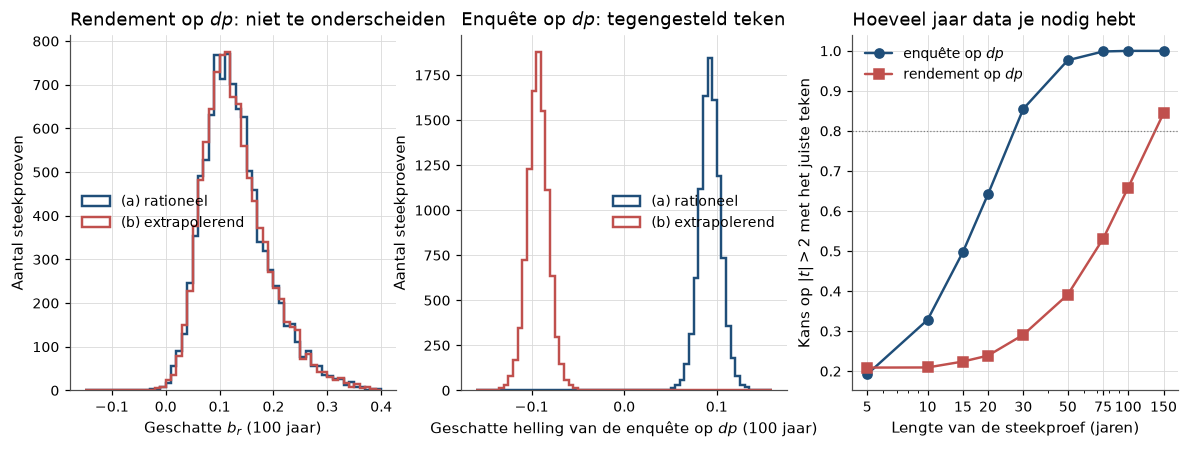

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for economy, colour, label in [("a", hap.plotting.COLORS[0], "(a) rationeel"),
                               ("b", hap.plotting.COLORS[1], "(b) extrapolerend")]:
    axes[0].hist(sim[economy]["b_r"], bins=np.linspace(-0.15, 0.40, 56), histtype="step",
                 lw=1.6, color=colour, label=label)
    axes[1].hist(sim[economy]["b_survey"], bins=np.linspace(-0.16, 0.16, 65), histtype="step",
                 lw=1.6, color=colour, label=label)
axes[0].set_title("Rendement op $dp$: niet te onderscheiden")
axes[0].set_xlabel("Geschatte $b_r$ (100 jaar)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
axes[1].set_title("Enquête op $dp$: tegengesteld teken")
axes[1].set_xlabel("Geschatte helling van de enquête op $dp$ (100 jaar)")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
axes[2].plot(power.index, power["enquête (a): t > 2"], marker="o", label="enquête op $dp$")
axes[2].plot(power.index, power["rendementen: t(b_r) > 2"], marker="s", label="rendement op $dp$")
axes[2].axhline(0.8, color="grey", lw=0.8, ls=":")
axes[2].set_xscale("log")
axes[2].set_xticks(years, [str(y) for y in years])
axes[2].set_title("Hoeveel jaar data je nodig hebt")
axes[2].set_xlabel("Lengte van de steekproef (jaren)")
axes[2].set_ylabel("Kans op $|t| > 2$ met het juiste teken")
axes[2].legend()
plt.show()

:::{figure} #cel-fama-vs-shiller-sim
:label: fig-fama-vs-shiller-sim
:width: 100%

Links: de verdeling van de voorspellende helling $\hat b_r$ over 10 000 steekproeven van
honderd jaar is in de rationele en de extrapolerende economie dezelfde; honderd jaar
koersen zegt niets over wie gelijk heeft. Midden: de helling van de enquête op $dp$ heeft
in de twee economieën een tegengesteld teken, en de verdelingen overlappen niet. Rechts:
de kans om het teken met $|t| > 2$ te zien. Voor de enquête is dertig jaar genoeg voor
ongeveer 85%; voor de rendementsregressie haalt zelfs honderd jaar maar twee op de drie.
:::

De simulatie maakt drie punten. De verdelingen van $\hat b_r$ vallen samen (de
Kolmogorov-Smirnov-toets verwerpt gelijkheid niet), met een gemiddelde van ongeveer
0,13 tegen een ware waarde van 0,093: de Stambaugh-bias uit [](#04-20-voorspelbaarheid),
in beide economieën even groot. De helling van de enquête op $dp$ ligt daarentegen met
een standaarddeviatie van ruim 0,01 rond $+0{,}093$ en $-0{,}093$, en de mediane helling van
het rendement op de enquête is ongeveer $+0{,}55$ en $-0{,}55$, dicht bij de populatiewaarde
uit [](#eq-fama-vs-shiller-tekens). En het 2%-motief keert om: om het teken van de
enquêteregressie in 80% van de steekproeven te zien, is tussen de twintig en dertig jaar nodig;
om de rendementsregressie even vaak significant te zien, meer dan een eeuw. Een enquête
heeft geen twintig procent rendementsruis aan de linkerkant.

```{warning}
De simulatie is gunstig voor enquêtes. Ze neemt aan dat de respondenten precies de
beleggers zijn wier overtuigingen de prijs zetten, dat de meetfout onafhankelijk is, en dat
de enquête in dezelfde eenheden staat als het verwachte rendement. Echte enquêtes zijn
herschaald, lopen door elkaar (particulieren, nieuwsbrieven, financieel directeuren), en
meten mogelijk wat mensen denken dat de vraag betekent. In [](#ex-fama-vs-shiller-1)
blijkt bovendien dat een mengsel van rationele en extrapolerende respondenten met
dezelfde enquêtehelling bij oneindig veel combinaties past.
```

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** (1) John H. Cochrane, *Presidential Address: Discount Rates*, Journal of Finance
2011 {cite}`Cochrane2011`. (2) Robin Greenwood en Andrei Shleifer, *Expectations of
Returns and Expected Returns*, Review of Financial Studies 2014
{cite}`GreenwoodShleifer2014`. (3) Robert J. Shiller, *Irrational Exuberance*, Princeton
University Press 2000 {cite}`Shiller2000`, als update van de CAPE-regressie uit
[](#01-03-williams-ddm).

**Wat.** (1) Tabel II: lange-termijncoëfficiënten $b_r^{(k)}$, $b_d^{(k)}$ en
$\rho^k b_{dp}^{(k)}$ over 1947–2009, direct met $k = 15$: $1{,}01$, $-0{,}11$, $-0{,}11$;
VAR met $k = 15$: $1{,}05$, $0{,}27$, $0{,}22$; VAR met $k = \infty$: $1{,}35$, $0{,}35$,
$0{,}00$. De onderliggende éénjaarsregressies (tabel III, rechts, 1947–2010): $b_r = 0{,}13$
($t = 2{,}61$, $R^2 = 0{,}10$), $b_d = 0{,}04$ ($t = 0{,}92$), $\phi = 0{,}94$ ($t = 23{,}8$).
(2) Tabel 4: de correlatie van de Graham-Harvey-enquête onder financieel directeuren
met log(D/P) is $-0{,}443$ ($N = 42$ kwartalen, 2000–2011); voor de zes enquêtes ligt ze
tussen $-0{,}193$ en $-0{,}567$. Tabel 5: in regressies van latere excess rendementen op
enquêteverwachtingen wordt de rationele nulhypothese $b = 1$ voor Graham-Harvey verworpen
($p = 0{,}000$ op twaalf maanden). (3) Het teken en de orde van grootte van de helling van
het reële tienjaarsrendement op log CAPE, bijgewerkt tot nu.

**Data hier.** (1) `hap.data.goyal_welch("annual")`, S&P 500-rendement met (`CRSP_SPvw`)
en zonder dividend (`CRSP_SPvwx`), dividenden geconstrueerd als in
[](#04-20-voorspelbaarheid), nominale logs. (2) De CFO Survey van Duke University en de
Federal Reserve Banks van Richmond en Atlanta {cite}`CFOSurvey2026`, de voortzetting van
de Graham-Harvey-enquête: het gemiddelde verwachte S&P 500-rendement over twaalf maanden,
kwartaaldata 2001Q4–2026Q2, via een kleine lokale loader die het werkboek één keer
downloadt en in `data/cache/` bewaart; daarnaast log(D/P) uit `hap.data.shiller()` en het
excess marktrendement uit `hap.data.market_monthly()`. (3) `hap.data.shiller()`,
decemberwaarnemingen van `cape` en `stock_real_return_10y` (het geannualiseerde reële
totaalrendement over de volgende tien jaar).

**Verschil met het origineel.** (1) Cochrane gebruikt de hele CRSP-markt, wij de S&P 500;
een iets andere $\hat\phi$ verandert de VAR-coëfficiënten sterk, omdat ze met
$1/(1-\rho\phi)$ worden opgeblazen. (2) Greenwood en Shleifer gebruiken zes enquêtes
(Gallup, Graham-Harvey, AAII, Investors Intelligence, Shiller, Michigan); daarvan is
alleen de CFO-enquête gratis en scriptbaar te downloaden. De AAII-site weigert een
geautomatiseerde download, en voor Shillers vertrouwensindices vonden we geen
downloadbaar bestand. Ons werkboek begint in 2001Q4 in plaats van 2000Q4, en we stempelen
elke enquête op het einde van de tweede maand van het kwartaal, omdat ze begin van de
derde maand sluit. (3) Geen verschil in data; de update is de periode na
[](#01-03-williams-ddm).

**Verwachte afwijking.** (1) Over 1947–2009 moeten de éénjaarshellingen binnen twee
standaardfouten van Cochrane's tabel III liggen, moet de directe $b_r^{(15)}$ tussen 0,8
en 1,3 liggen en $b_d^{(15)}$ binnen 0,3 van nul, en moeten de drie termen van
[](#eq-fama-vs-shiller-schema) tot op 0,02 optellen tot één: bijna alle variantie in P/D
via verwachte rendementen. (2) De correlatie tussen de CFO-verwachting en log(D/P) moet
negatief zijn (dus positief met P/D), in de orde van $-0{,}3$ tot $-0{,}6$ over 2001–2011,
en de helling van het latere twaalfmaands excess rendement op de CFO-verwachting mag niet
significant positief zijn. Wijkt een van die twee tekens af, dan zit de fout in de code.
(3) De helling op log CAPE moet negatief zijn met $|t| > 2$.
```

### (1) Cochrane's decompositie

In [6]:
gw = hap_data.goyal_welch("annual")
gw.index = gw.index.year
div_yield = (1 + gw["CRSP_SPvw"]) / (1 + gw["CRSP_SPvwx"]) - 1
price_idx = (1 + gw["CRSP_SPvwx"]).cumprod()
annual = pd.DataFrame({"r": np.log1p(gw["CRSP_SPvw"]),
                       "dd": np.log(div_yield * price_idx).diff(),
                       "dp": np.log(div_yield)})


def cochrane_decomposition(first, last, k=15):
    """Cochrane (2011) Tables II-III: one-year VAR and the long-run coefficients of eq. schema."""
    s = annual.loc[first - 1:last]
    rho = np.exp(-s["dp"].mean()) / (1 + np.exp(-s["dp"].mean()))
    one_year = {}
    for col in ["r", "dd", "dp"]:
        f = pd.concat([s[col].rename("y"), s["dp"].shift(1).rename("x")], axis=1).dropna()
        fit = sm.OLS(f["y"], sm.add_constant(f["x"])).fit()
        one_year[col] = (fit.params["x"], fit.tvalues["x"], fit.rsquared)
    b_r, b_d, phi = one_year["r"][0], one_year["dd"][0], one_year["dp"][0]
    a = rho * phi
    weights = rho ** np.arange(k)
    direct = {}
    for col, name in [("r", "b_r"), ("dd", "b_d")]:
        future = sum(weights[j] * s[col].shift(-(j + 1)) for j in range(k))
        f = pd.concat([future.rename("y"), s["dp"].rename("x")], axis=1).dropna()
        direct[name] = sm.OLS(f["y"], sm.add_constant(f["x"])).fit().params["x"]
    f = pd.concat([(rho**k * s["dp"].shift(-k)).rename("y"), s["dp"].rename("x")], axis=1).dropna()
    direct["rho^k b_dp"] = sm.OLS(f["y"], sm.add_constant(f["x"])).fit().params["x"]
    long_run = pd.DataFrame(
        {"direct": direct,
         "VAR, zelfde k": {"b_r": b_r * (1 - a**k) / (1 - a), "b_d": b_d * (1 - a**k) / (1 - a),
                           "rho^k b_dp": a**k},
         "VAR, k=inf": {"b_r": b_r / (1 - a), "b_d": b_d / (1 - a), "rho^k b_dp": 0.0}}
    ).T
    long_run["som"] = long_run["b_r"] - long_run["b_d"] + long_run["rho^k b_dp"]
    return one_year, rho, long_run


one_0909, rho_0909, lr_0909 = cochrane_decomposition(1947, 2009)
_, _, lr_4725 = cochrane_decomposition(1947, 2025)
print("één jaar, 1947-2009 (b, t, R2):",
      {c: tuple(round(float(v), 3) for v in vals) for c, vals in one_0909.items()},
      f" rho = {rho_0909:.4f}")
print("Cochrane tabel III (1947-2010):  r 0.13 (2.61) 0.10 | dd 0.04 (0.92) 0.02 | dp 0.94 (23.8) 0.91")
cochrane_table2 = pd.DataFrame({"b_r": [1.01, 1.05, 1.35], "b_d": [-0.11, 0.27, 0.35],
                                "rho^k b_dp": [-0.11, 0.22, 0.00]}, index=lr_0909.index)
cochrane_table2["som"] = cochrane_table2["b_r"] - cochrane_table2["b_d"] + cochrane_table2["rho^k b_dp"]
pd.concat({"hier 1947-2009": lr_0909, "Cochrane tabel II (k=15)": cochrane_table2,
           "hier 1947-2025": lr_4725}).round(3)

één jaar, 1947-2009 (b, t, R2): {'r': (0.131, 2.88, 0.12), 'dd': (0.053, 1.463, 0.034), 'dp': (0.952, 23.793, 0.903)}  rho = 0.9669
Cochrane tabel III (1947-2010):  r 0.13 (2.61) 0.10 | dd 0.04 (0.92) 0.02 | dp 0.94 (23.8) 0.91


b_r    b_d  rho^k b_dp    som
hier 1947-2009           direct         1.164 -0.010      -0.184  0.990
                         VAR, zelfde k  1.174  0.473       0.289  0.989
                         VAR, k=inf     1.651  0.666       0.000  0.985
Cochrane tabel II (k=15) direct         1.010 -0.110      -0.110  1.010
                         VAR, zelfde k  1.050  0.270       0.220  1.000
                         VAR, k=inf     1.350  0.350       0.000  1.000
hier 1947-2025           direct         0.732 -0.100       0.168  1.000
                         VAR, zelfde k  0.943  0.388       0.460  1.014
                         VAR, k=inf     1.745  0.719       0.000  1.027

Op Cochrane's periode komen de éénjaarsregressies uit op $\hat b_r = 0{,}131$
($t = 2{,}88$), $\hat b_d = 0{,}053$ en $\hat\phi = 0{,}952$, tegen $0{,}13$, $0{,}04$ en
$0{,}94$ in zijn tabel III. De directe decompositie over vijftien jaar geeft
$b_r^{(15)} = 1{,}16$, $b_d^{(15)} = -0{,}01$ en een eindterm van $-0{,}18$, tegen $1{,}01$,
$-0{,}11$ en $-0{,}11$: in beide gevallen draagt het verwachte rendement alles en de
dividendgroei niets. De VAR-rijen wijken meer af ($1{,}65$ en $0{,}67$ voor
$k = \infty$ tegen $1{,}35$ en $0{,}35$), en dat is precies de gevoeligheid die het
replicatieblok aankondigde: bij $\rho\hat\phi = 0{,}92$ in plaats van $0{,}90$ is
$1/(1-\rho\phi)$ een kwart groter. In alle rijen tellen de drie termen op tot tussen
0,985 en 1,01: de identiteit geldt in de data op enkele duizendsten na.

Tot 2025 verandert het beeld op één punt. De directe $b_r^{(15)}$ zakt naar $0{,}73$, de
dividendterm blijft dicht bij nul, en de eindterm stijgt naar $0{,}17$: een zesde van de
beweging in de ratio is na vijftien jaar nog niet "terugbetaald". Dat is de lage
dividend-prijsratio na 1995, die ook in [](#04-20-voorspelbaarheid) de
voorspellingsregressie verzwakte. Of dat een permanent lagere discontovoet is, een
verschuiving van dividend naar inkoop van eigen aandelen, of een trage bel, zegt het
schema niet; het zegt alleen dat de eindterm, die op Cochrane's steekproef rond nul lag,
op de langere steekproef niet meer nul is.

### (2) Enquêteverwachtingen: de CFO-enquête

In [7]:
CFO_URL = ("https://www.richmondfed.org/-/media/RichmondFedOrg/research/national_economy/"
           "cfo_survey/current_historical_cfo_data.xlsx")


@hap.cache.cached("cfo_survey")
def cfo_survey() -> pd.DataFrame:
    """CFO Survey (Duke / Richmond Fed / Atlanta Fed): mean expected S&P 500 return.

    Columns ``sp_1_exp`` (next 12 months) and ``sp_10_exp`` (next 10 years), decimals,
    quarterly from 2001Q4, stamped at the end of the second month of the survey quarter
    (the survey closes early in the third month). Sheet ``through_Q1_2020`` holds the
    Graham-Harvey history, sheet ``CFO_SP500`` the continuation from 2020Q3.
    """  # TODO: naar hap.data
    payload = requests.get(CFO_URL, timeout=180, headers={"User-Agent": "Mozilla/5.0"}).content
    cols = ["year", "quarter", "sp_1_exp", "sp_10_exp"]
    old = pd.read_excel(io.BytesIO(payload), sheet_name="through_Q1_2020")[cols]
    new = pd.read_excel(io.BytesIO(payload), sheet_name="CFO_SP500")[
        ["year", "quarter", "sp_12moexp_2", "sp_10yrexp_2"]].set_axis(cols, axis=1)
    frame = pd.concat([old, new], ignore_index=True).dropna(subset=["sp_1_exp"])
    stamps = [pd.Timestamp(int(y), 3 * int(q) - 1, 1) + pd.offsets.MonthEnd(0)
              for y, q in zip(frame["year"], frame["quarter"])]
    frame.index = pd.DatetimeIndex(stamps, name="date")
    return frame[["sp_1_exp", "sp_10_exp"]] / 100.0


cfo = cfo_survey()
shiller = hap_data.shiller()
mkt = hap_data.market_monthly()
log_excess = np.log1p(mkt["Mkt"]) - np.log1p(mkt["RF"])
survey_panel = pd.concat(
    [cfo["sp_1_exp"].rename("enquete"),
     np.log(shiller["dp"]).rename("log_dp"),
     np.log1p(mkt["Mkt"]).rolling(12).sum().rename("rendement_vorig_jaar"),
     log_excess.rolling(12).sum().shift(-12).rename("excess_volgend_jaar")],
    axis=1, sort=True,
).loc[cfo.index]
print(f"{cfo.index[0]:%Y-%m} t/m {cfo.index[-1]:%Y-%m}: {len(cfo)} kwartalen; "
      f"gemiddelde verwachting {cfo['sp_1_exp'].mean():.2%}, sd {cfo['sp_1_exp'].std():.2%}")

early = survey_panel.loc[:"2011-12"]
pd.DataFrame(
    {"corr(enquête, log D/P)": [early["enquete"].corr(early["log_dp"]),
                                survey_panel["enquete"].corr(survey_panel["log_dp"]), -0.443],
     "N": [len(early[["enquete", "log_dp"]].dropna()),
           len(survey_panel[["enquete", "log_dp"]].dropna()), 42]},
    index=["hier 2001-2011", "hier 2001-2026", "Greenwood-Shleifer tabel 4 (2000-2011)"],
).round(3)

2001-11 t/m 2026-05: 96 kwartalen; gemiddelde verwachting 5.43%, sd 1.42%


,"corr(enquête, log D/P)",N
hier 2001-2011,-0.545,41
hier 2001-2026,-0.411,96
Greenwood-Shleifer tabel 4 (2000-2011),-0.443,42


In [8]:
specs = [("enquete", ["log_dp"], 4), ("enquete", ["rendement_vorig_jaar", "log_dp"], 4),
         ("excess_volgend_jaar", ["enquete"], 6), ("excess_volgend_jaar", ["log_dp"], 6)]
reg_rows = {}
for y, xs, lags in specs:
    fit = hap.newey_west(survey_panel[y], survey_panel[xs], lags=lags)
    reg_rows[f"{y} op {' + '.join(xs)}"] = {
        **{f"b({x})": fit.params[x] for x in xs}, **{f"t({x})": fit.tvalues[x] for x in xs},
        "R2": fit.rsquared, "N": int(fit.nobs)}
fit_b1 = hap.newey_west(survey_panel["excess_volgend_jaar"], survey_panel[["enquete"]], lags=6)
print(f"toets b = 1 in de voorspellingsregressie: t = "
      f"{(fit_b1.params['enquete'] - 1) / fit_b1.bse['enquete']:.2f}")
pd.DataFrame(reg_rows).T.round(3)

toets b = 1 in de voorspellingsregressie: t = -1.61


,b(log_dp),t(log_dp),R2,N,b(rendement_vorig_jaar),t(rendement_vorig_jaar),b(enquete),t(enquete)
enquete op log_dp,-0.029,-3.733,0.169,96.0,NaN,NaN,NaN,NaN
enquete op rendement_vorig_jaar + log_dp,-0.020,-1.788,0.221,96.0,0.022,1.439,NaN,NaN
excess_volgend_jaar op enquete,NaN,NaN,0.015,92.0,NaN,NaN,-1.396,-0.941
excess_volgend_jaar op log_dp,0.250,2.086,0.079,92.0,NaN,NaN,NaN,NaN


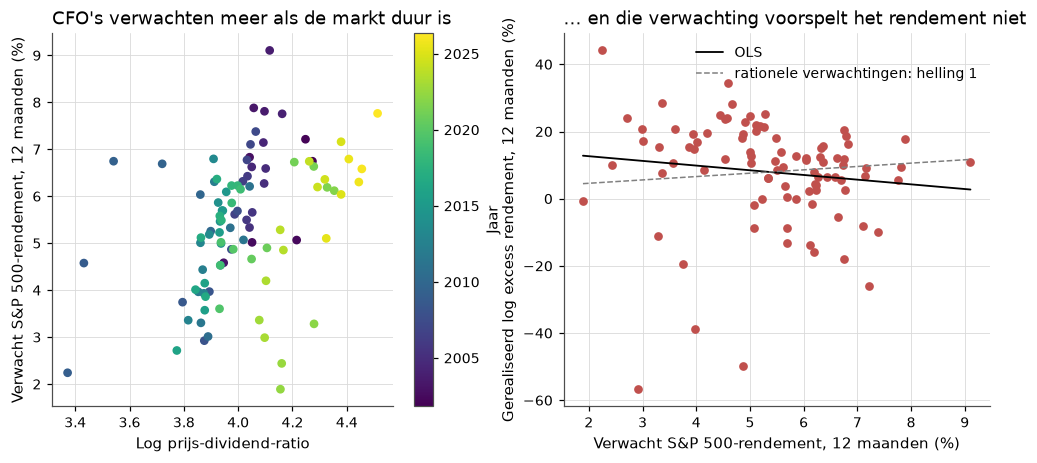

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
year_frac = survey_panel.index.year + (survey_panel.index.month - 1) / 12
sc = axes[0].scatter(-survey_panel["log_dp"], 100 * survey_panel["enquete"], c=year_frac,
                     cmap="viridis", s=22)
axes[0].set_xlabel("Log prijs-dividend-ratio")
axes[0].set_ylabel("Verwacht S&P 500-rendement, 12 maanden (%)")
axes[0].set_title("CFO's verwachten meer als de markt duur is")
fig.colorbar(sc, ax=axes[0], label="Jaar")
ok = survey_panel[["enquete", "excess_volgend_jaar"]].dropna()
line = np.polyfit(ok["enquete"], ok["excess_volgend_jaar"], 1)
grid = np.linspace(ok["enquete"].min(), ok["enquete"].max(), 50)
axes[1].scatter(100 * ok["enquete"], 100 * ok["excess_volgend_jaar"], s=22, color=hap.plotting.COLORS[1])
axes[1].plot(100 * grid, 100 * np.polyval(line, grid), color="black", lw=1.2, label="OLS")
axes[1].plot(100 * grid, 100 * (grid - ok["enquete"].mean() + ok["excess_volgend_jaar"].mean()),
             color="grey", lw=1.0, ls="--", label="rationele verwachtingen: helling 1")
axes[1].set_xlabel("Verwacht S&P 500-rendement, 12 maanden (%)")
axes[1].set_ylabel("Gerealiseerd log excess rendement, 12 maanden (%)")
axes[1].set_title("... en die verwachting voorspelt het rendement niet")
axes[1].legend()
plt.show()

:::{figure} #cel-fama-vs-shiller-cfo
:label: fig-fama-vs-shiller-cfo
:width: 100%

De CFO-enquête, 2001–2026. Links: de verwachting van financieel directeuren stijgt met de
prijs-dividend-ratio, het teken van economie (b) en van Greenwood en Shleifer. Rechts: de
helling van het latere excess rendement op de verwachting is negatief en onnauwkeurig,
ver van de helling één die rationele verwachtingen eisen. Met ruim negentig overlappende
kwartalen is de rechterfiguur vooral ruis: het 2%-motief aan de rendementskant.
:::

De tekens kloppen met Greenwood en Shleifer. Over 2001–2011 is de correlatie tussen de
CFO-verwachting en log(D/P) $-0{,}55$, tegen $-0{,}443$ in hun tabel 4; over de volle
steekproef tot 2026 is ze $-0{,}41$. Een regressie van de verwachting op log(D/P) geeft
een helling van ongeveer $-0{,}03$ ($t = -3{,}7$): een log-punt duurdere markt gaat samen
met een drie procentpunt hogere verwachting. Economie (a) voorspelde het omgekeerde teken,
met een helling in de orde van $+0{,}09$ tot $+0{,}13$. Het rendement van het afgelopen jaar
komt er met een positief teken bij ($t = 1{,}4$), zoals bij extrapolatie hoort. Aan de rendementskant is
de helling van het latere twaalfmaands excess rendement op de verwachting negatief
($-1{,}4$, $t = -0{,}9$) en insignificant, terwijl log(D/P) in dezelfde steekproef met het juiste teken
voorspelt. De nulhypothese $b = 1$ halen we met deze ene enquête niet formeel onderuit ($t = -1{,}6$);
Greenwood en Shleifer, met langere reeksen en meer enquêtes, wel.

Hoe sterk is dit bewijs? Aan de enquêtekant sterk: bijna honderd kwartalen en een
$t$-waarde van $-3{,}7$, de meetbaarheid die de simulatie beloofde. Maar de simulatie liet
ook zien wat de enquête niet uitsluit. Als financieel directeuren niet de marginale
beleggers zijn, zegt hun extrapolatie weinig over de $\xi$ van wie de prijs zet, en de
rationele lezing kan volhouden dat de marginale belegger (een pensioenfonds, een
intermediair) na een crash wel hoge rendementen verwacht. Het teken van de enquête bewijst
dat *iemand* extrapoleert, niet dat die iemand de prijs bepaalt.

### (3) Shillers CAPE, bijgewerkt

In [](#01-03-williams-ddm) regresseerden we het reële tienjaarsrendement op log CAPE over
de hele steekproef tot 2015. Hier alleen de update, zonder vooruitkijken: we schatten de
regressie op beginjaren tot en met 2006 (waarvan de uitkomsten in 2016 bekend waren),
voorspellen de beginjaren 2007–2015, en maken daarna een voorspelling vanaf de huidige
CAPE met de regressie op alle beginjaren tot en met 2016.

In [10]:
december = shiller[shiller.index.month == 12][["cape", "stock_real_return_10y"]].copy()
december.index = december.index.year
december["log_cape"] = np.log(december["cape"])


def cape_fit(last_start):
    """HAC regression of the annualised 10-year real return on log CAPE, start years up to last_start."""
    d = december.loc[:last_start].dropna()
    return hap.newey_west(d["stock_real_return_10y"], d[["log_cape"]], lags=9)


fit_2006, fit_2016 = cape_fit(2006), cape_fit(2016)
update = december.loc[2007:2015, ["cape", "stock_real_return_10y"]].rename(
    columns={"stock_real_return_10y": "gerealiseerd"})
update["voorspeld (fit t/m 2006)"] = (fit_2006.params["const"]
                                      + fit_2006.params["log_cape"] * np.log(update["cape"]))
cape_now = shiller["cape"].dropna()
forecast_now = fit_2016.params["const"] + fit_2016.params["log_cape"] * np.log(cape_now.iloc[-1])
print(f"helling t/m 2006: {fit_2006.params['log_cape']:.4f} (t = {fit_2006.tvalues['log_cape']:.2f}), "
      f"R2 = {fit_2006.rsquared:.2f}, n = {int(fit_2006.nobs)}")
print(f"helling t/m 2016: {fit_2016.params['log_cape']:.4f} (t = {fit_2016.tvalues['log_cape']:.2f}), "
      f"R2 = {fit_2016.rsquared:.2f}, n = {int(fit_2016.nobs)}")
errors = update["gerealiseerd"] - update["voorspeld (fit t/m 2006)"]
print(f"gemiddelde fout 2007-2015: {errors.mean():+.3f}; correlatie voorspeld-gerealiseerd: "
      f"{update['gerealiseerd'].corr(update['voorspeld (fit t/m 2006)']):.2f}")
print(f"CAPE {cape_now.index[-1]:%Y-%m}: {cape_now.iloc[-1]:.1f} -> voorspeld reëel rendement "
      f"{forecast_now:.2%} per jaar (residu-sd {np.sqrt(fit_2016.scale):.1%})")
update.round(3)

helling t/m 2006: -0.0745 (t = -6.56), R2 = 0.33, n = 126
helling t/m 2016: -0.0632 (t = -4.56), R2 = 0.24, n = 135
gemiddelde fout 2007-2015: +0.071; correlatie voorspeld-gerealiseerd: 0.52
CAPE 2026-09: 40.6 -> voorspeld reëel rendement 0.59% per jaar (residu-sd 4.5%)


,cape,gerealiseerd,voorspeld (fit t/m 2006)
date,,,
2007,25.956,0.066,0.023
2008,15.376,0.116,0.063
2009,20.322,0.114,0.042
2010,22.396,0.118,0.034
2011,20.524,0.139,0.041
2012,21.238,0.099,0.038
2013,24.862,0.090,0.027
2014,26.794,0.100,0.021
2015,25.965,0.112,0.023


De helling is negatief en ruim significant: $-0{,}075$ ($t = -6{,}6$) op beginjaren tot
2006, $-0{,}063$ ($t = -4{,}6$) tot 2016. Maar de voorspellingen voor 2007–2015 zaten er
gemiddeld zeven procentpunt per jaar naast, en steeds aan de lage kant: een CAPE van 26 in
2007 beloofde reëel 2,3% per jaar en leverde 6,6% op; de CAPE van 15 in 2008 beloofde 6,3% en
leverde 11,6%. De *rangorde* klopte (correlatie 0,52), het *niveau* niet. In september 2026
staat de voorlopige CAPE op 40,6, na december 1999 de hoogste decemberwaarde sinds 1881,
en de regressie voorspelt een reëel rendement van ongeveer 0,6% per jaar, met een
residuele standaarddeviatie van 4,5 procentpunt en een steekproef die in feite uit
dertien onafhankelijke decennia bestaat.

Die fout van zeven procentpunt is zelf een test van de twee lezingen, en ze beslist niet.
De Chicago-lezing: de discontovoet is na 2008 blijvend gedaald, samen met de reële rente,
dus een hoge CAPE is een lage premie en geen overwaardering, en een regressie met een
constant gemiddelde moest te laag uitkomen. De Yale-lezing: de markt is steeds duurder
geworden omdat beleggers de hausse extrapoleerden, en de correctie is uitgesteld, niet
afgeschaft. De lage rendementen na de CAPE-top van 1999 gaven Shiller gelijk, de hoge
rendementen na 2009 niet.

## Wat er brak, en wat daarna kwam

**Wat het debat opleverde.** Een feit dat vaststaat en een formulering die vaststaat. Het
feit: de variatie in de prijs-dividend-ratio is variatie in verwachte rendementen. Op
Cochrane's periode vinden we een directe lange-termijncoëfficiënt van 1,16 voor
rendementen en $-0{,}01$ voor dividendgroei, en honderd jaar gesimuleerde data laat zien
dat dat feit in een rationele en in een extrapolerende economie hetzelfde is. De
formulering: elk model van de discontovoet is een keuze voor $(\tilde{\mathbb P}, \tilde m)$,
en prijzen identificeren alleen hun product ({prf:ref}`prop-fama-vs-shiller-equivalentie`).
Dat maakte van een ideologisch debat een meetprobleem met een duidelijke opdracht: meet
$\xi$ of meet $m$ apart.

**Waar het breekt.** Op het eerste meetinstrument dat beide kampen serieus namen. Enquêtes
geven het teken van Yale: de CFO-verwachting correleert over 2001–2011 met $-0{,}55$ met
log(D/P) en voorspelt latere rendementen met een negatieve helling, zoals Greenwood en
Shleifer met zes enquêtes vonden. Dat is het sterkste bewijs tegen de zuiver rationele
lezing, want economie (a) voorspelt het tegenovergestelde teken, en de simulatie laat
zien dat twintig à dertig jaar enquêtedata genoeg is om dat verschil te zien. Tegelijk is de
eindterm van de decompositie tot 2025 niet meer nul, en zat de CAPE-voorspelling sinds
2007 systematisch te laag: de feiten zelf bewegen.

**Risico of vergissing?** Hier kiest de reeks, zoals beloofd, nog steeds niet. De
Chicago-lezing van de enquêtes: financieel directeuren, particulieren en
nieuwsbriefschrijvers zijn niet de marginale belegger; de prijs wordt gezet door wie de
risico's draagt, en voor die groep zijn er geen enquêtes. Martins optiegrens
([](#05-29-opties-crashrisico)) en de intermediairfactor ([](#05-32-intermediaries))
zeggen dat verwachte rendementen juist in crises het hoogst zijn, zoals economie (a)
voorspelt. De Yale-lezing: als de verwachtingen van iedereen die we kunnen vragen het
verkeerde teken hebben, is een marginale belegger die wél rationeel is een postulaat en
geen waarneming, en verklaart een model met extrapolatoren en een beperkte rationele
tegenpartij dezelfde prijzen plús de enquêtes. De middenwegen van Adam, Marcet en Beutel en
van Nagel en Xu laten zien dat de grens zelf vervaagt: beleggers die volkomen rationeel
handelen op overtuigingen die ze uit hun ervaring leren. Welke data zou beslissen? De
verwachtingen en de posities van de beleggers die de prijs *zetten*, op hetzelfde moment
gemeten. Die data bestaan gedeeltelijk, in flows en bezitsgegevens, en daar ging het vak
heen. Santa-Clara's praktijkmotief geeft beide lezingen dezelfde les: wie koopt als de
enquêtes somber zijn, draagt ofwel beprijsd risico, ofwel profiteert hij van de vergissing
van anderen, en in beide gevallen verdient hij alleen als hij het kan volhouden.

**Wat er daarna kwam.** Cochrane's rede noemde een tweede feit dat evenmin een theorie had:
in de cross-sectie "Now we have a zoo of new factors". Hoeveel van die honderden
voorspellers echt zijn, is de vraag van [](#06-34-factor-zoo).

## Oefeningen

:::{exercise}
:label: ex-fama-vs-shiller-1

**Een mengsel van respondenten.** Stel dat een fractie $w$ van de enquêterespondenten
extrapoleert zoals in economie (b), met gevoeligheid $\theta$, en dat de rest rationeel is
zoals in economie (a). De prijzen zijn die van economie (a); de enquête is het gemiddelde
antwoord.

1. Laat zien dat de helling van de enquête op $dp_t$ gelijk is aan $(1-w)K - w\theta$, en
   geef de helling van $r_{t+1}$ op de enquête in termen van $w$, $\theta$, $K$, $V$ en
   $\sigma_\eta^2$.
2. Neem $K = 0{,}093$ en de CFO-helling van $-0{,}029$ uit de replicatie. Welke $w$ past
   bij $\theta = K$? En bij $\theta = 2K$?
3. Controleer (1) met een simulatie van 5000 steekproeven van 100 jaar voor beide
   combinaties uit (2). Wat identificeert een enquêtehelling wel, en wat niet?
:::

:::{solution} ex-fama-vs-shiller-1
:class: dropdown

**(1)** De enquête is $(1-w)(K\,dp_t) + w(-\theta\,dp_t) + \eta_t = a\,dp_t + \eta_t$ met
$a = (1-w)K - w\theta$, dus de helling op $dp_t$ is $a$. Het objectieve verwachte
rendement is $K\,dp_t$, dus volgens [](#eq-fama-vs-shiller-tekens) is
$\beta(r_{t+1}, \E^{s}_t) = aKV/(a^2V + \sigma_\eta^2)$.

**(2)** $(1-w)K - w\theta = -0{,}029$ geeft $w = (K + 0{,}029)/(K + \theta)$. Met
$\theta = K$: $w = 0{,}122/0{,}186 = 0{,}656$. Met $\theta = 2K$: $w = 0{,}122/0{,}279 = 0{,}437$.

**(3)**

In [11]:
def simulate_mixture(n, T, w, theta):
    """Economy (a) prices with a survey mixing rational (1 - w) and extrapolative (w) answers."""
    dp, returns, _ = simulate_economy(n, T, "a", sd_survey=0.0)
    belief = (1 - w) * K * dp - w * theta * dp
    return dp, returns, belief + rng.normal(0.0, SD_SURVEY, dp.shape)


rows_mix = {}
for w_mix, theta_mix in [(0.656, K), (0.437, 2 * K)]:
    dp_m, r_m, s_m = simulate_mixture(5000, 100, w_mix, theta_mix)
    a_mix = (1 - w_mix) * K - w_mix * theta_mix
    rows_mix[f"w = {w_mix}, theta = {theta_mix / K:.0f}K"] = {
        "helling enquête op dp (sim)": ols_rows(s_m, dp_m)[0].mean(),
        "helling (formule)": a_mix,
        "helling r op enquête (sim, mediaan)": np.median(ols_rows(r_m, s_m[:, :-1])[0]),
        "helling r op enquête (formule)": a_mix * K * var_dp / (a_mix**2 * var_dp + SD_SURVEY**2),
    }
pd.DataFrame(rows_mix).T.round(3)

,helling enquête op dp (sim),helling (formule),"helling r op enquête (sim, mediaan)",helling r op enquête (formule)
"w = 0.656, theta = 1K",-0.029,-0.029,-0.281,-0.312
"w = 0.437, theta = 2K",-0.029,-0.029,-0.284,-0.311


Beide combinaties geven dezelfde enquêtehelling van ongeveer $-0{,}03$ en dezelfde, zwak
negatieve helling van rendementen op de enquête. Een enquête identificeert de *netto*
afwijking van rationele verwachtingen, niet hoeveel beleggers extrapoleren of hoe sterk:
de gelijkwaardigheid van {prf:ref}`prop-fama-vs-shiller-equivalentie` schuift een laag op.
:::

:::{exercise}
:label: ex-fama-vs-shiller-2

**De decompositie op andere horizonten en steekproeven.** Herhaal de directe
decompositie [](#eq-fama-vs-shiller-schema) met `cochrane_decomposition` voor
$k = 10$ en $k = 20$, over 1927–2025, 1947–2009 en 1947–2025. Hoe verandert de
eindterm $\rho^k b_{dp}^{(k)}$ met de horizon en met de steekproef, en wat betekent dat
voor Cochrane's "none to rational bubbles"?
:::

:::{solution} ex-fama-vs-shiller-2
:class: dropdown

In [12]:
rows_k = {}
for first, last in [(1927, 2025), (1947, 2009), (1947, 2025)]:
    for k in (10, 20):
        rows_k[(f"{first}-{last}", k)] = cochrane_decomposition(first, last, k=k)[2].loc["direct"]
pd.DataFrame(rows_k).T.rename_axis(["steekproef", "k"]).round(3)

b_r    b_d  rho^k b_dp    som
steekproef k                                  
1927-2025  10  0.458 -0.072       0.468  0.997
           20  0.624 -0.176       0.195  0.994
1947-2009  10  0.892  0.114       0.200  0.978
           20  1.048 -0.265      -0.301  1.012
1947-2025  10  0.639 -0.038       0.327  1.003
           20  0.681 -0.179       0.138  0.998

Over 1947–2009 draagt $b_r^{(k)}$ het grootste deel: 0,89 bij $k = 10$ en 1,05 bij
$k = 20$. Zodra de steekproef tot 2025 doorloopt, en nog meer vanaf 1927, blijft een
groter deel van de beweging na $k$ jaar in de ratio zelf zitten: over 1927–2025 is de
eindterm bij $k = 10$ met 0,47 even groot als $b_r^{(10)}$, en pas bij $k = 20$ zakt hij
naar 0,20. Op een langere
steekproef is de dividend-prijsratio persistenter, en dan valt bij een eindige horizon
een deel van de variantie buiten beeld. Dat is geen bewijs voor een bel, maar het zwakt
het woord "none" af: het oordeel over de eindterm hangt af van hoe ver je kijkt, en
daarmee van de schatting van $\phi$ die in [](#04-20-voorspelbaarheid) al de zwakke
plek was.
:::

:::{exercise}
:label: ex-fama-vs-shiller-3

**Hoeveel enquêtejaren bij meer meetfout?** Herhaal de machtsberekening uit de simulatie
voor een meetfout in de enquête van 2, 4 en 8 procentpunt. Rapporteer voor elk het
kleinste aantal jaren uit $\{5, 10, 15, 20, 30, 50, 75, 100\}$ waarbij de enquêteregressie
in economie (a) in minstens 80% van de steekproeven $t > 2$ geeft. Leid een vuistregel af
voor hoe dat aantal met de meetfout schaalt.
:::

:::{solution} ex-fama-vs-shiller-3
:class: dropdown

In [13]:
needed = {}
for sd_eta in (0.02, 0.04, 0.08):
    needed[sd_eta] = np.nan
    for T_years in [5, 10, 15, 20, 30, 50, 75, 100]:
        dp_n, _, s_n = simulate_economy(4000, T_years, "a", sd_survey=sd_eta)
        if np.mean(ols_rows(s_n, dp_n)[1] > 2) >= 0.8:
            needed[sd_eta] = T_years
            break
pd.Series(needed, name="jaren nodig voor 80% kans").rename_axis("meetfout enquête").to_frame()

,jaren nodig voor 80% kans
meetfout enquête,
0.02,15
0.04,30
0.08,75


Bij 2, 4 en 8 procentpunt meetfout zijn 15, 30 en 75 jaar nodig. De standaardfout van de helling is ongeveer $\sigma_\eta/(\sqrt{T}\,\sigma_{dp,T})$, met
$\sigma_{dp,T}$ de spreiding van $dp$ binnen een steekproef van $T$ jaar. Bij een vaste
$\sigma_{dp,T}$ zou een verdubbeling van de meetfout vier keer zoveel jaren vragen. Omdat
een langere steekproef ook meer van de trage beweging in $dp$ ziet, groeit
$\sigma_{dp,T}$ mee met $T$, en is de toename in de praktijk kleiner dan een factor
vier: een verdubbeling van de meetfout vraagt hier twee à tweeënhalf keer zoveel jaren.
Les: bij een ruis van 8 procentpunt heeft ook een enquête driekwart eeuw nodig, en dan
verdwijnt haar voordeel op de rendementsregressie grotendeels. Hoe goed een enquête
meet, is daarom net zo belangrijk als de vraag of de respondenten de prijs zetten.
:::